# 06 — PCA Experiment

**EduPredict — Student Exam Performance Prediction**

This notebook evaluates PCA as a dimensionality-reduction experiment.

PCA is **not automatically forced into production**. We will compare:

- a baseline model without PCA
- PCA pipelines with data-driven component counts

The decision will be based on:
- explained variance,
- validation RMSE/MAE/R²,
- dimensionality reduction,
- and interpretability.

**Leakage control:** PCA is fitted inside the training pipeline only. The locked test set is not used for choosing the number of components.

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [14]:
DATA_PATH = Path("../data/processed/student_performance_engineered.csv")
SELECTED_FEATURES_PATH = Path("../outputs/metrics/selected_features.json")

df_fe = pd.read_csv(DATA_PATH)
TARGET = "Exam_Score"

X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET]

print("Dataset shape:", df_fe.shape)
print("Candidate input features:", X.shape[1])

Dataset shape: (6606, 22)
Candidate input features: 21


## 1. Load the feature-selection decision

The previous notebook may have selected a reduced feature set or retained all candidate features.

We use the saved decision rather than manually changing the feature list.

In [15]:
if SELECTED_FEATURES_PATH.exists():
    with open(SELECTED_FEATURES_PATH, "r", encoding="utf-8") as f:
        selection_info = json.load(f)

    selected_features = selection_info["features"]
    selection_decision = selection_info["decision"]

    print("Feature-selection decision:")
    print(selection_decision)
    print("\nFeatures available for PCA:", len(selected_features))
else:
    selected_features = X.columns.tolist()
    selection_decision = "Feature-selection artifact not found; using all candidate features."

    print(selection_decision)

Feature-selection decision:
Use permutation-selected features as the candidate reduced feature set.

Features available for PCA: 17


In [16]:
X_selected = X[selected_features].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42
)

X_train_pca, X_valid_pca, y_train_pca, y_valid_pca = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train_pca))
print("Validation rows:", len(X_valid_pca))
print("Locked test rows:", len(X_test))
print("Input features:", X_selected.shape[1])

Training rows: 4227
Validation rows: 1057
Locked test rows: 1322
Input features: 17


## 2. Build the preprocessing pipeline

PCA operates on numerical matrices.

Because the dataset contains both numerical and categorical variables:

1. numerical features are median-imputed and standardized;
2. categorical features are most-frequent imputed and one-hot encoded;
3. the resulting feature matrix is standardized;
4. PCA is then fitted.

All transformations are inside a pipeline so that fitting happens only on the training data.

In [17]:
numeric_features = X_train_pca.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train_pca.select_dtypes(
    include=["object", "str"]
).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 6
Categorical features: 11


## 3. Inspect the transformed dimensionality

Before selecting PCA components, determine how many dimensions exist **after preprocessing**.

This is important because one-hot encoding expands categorical variables.

In [18]:
X_train_transformed = preprocessor.fit_transform(X_train_pca)

print("Preprocessed training matrix shape:", X_train_transformed.shape)
print("Original raw feature count:", X_selected.shape[1])
print("Post-preprocessing dimensions:", X_train_transformed.shape[1])

Preprocessed training matrix shape: (4227, 36)
Original raw feature count: 17
Post-preprocessing dimensions: 36


In [19]:
# Fit a full PCA only to inspect explained variance.
pca_full = PCA()
pca_full.fit(X_train_transformed)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

variance_levels = {}

for threshold in [0.80, 0.90, 0.95, 0.99]:
    components = np.argmax(
        cumulative_variance >= threshold
    ) + 1
    variance_levels[threshold] = int(components)

print("Components required for explained-variance thresholds:")
for threshold, components in variance_levels.items():
    print(f"{threshold:.0%}: {components}")

Components required for explained-variance thresholds:
80%: 17
90%: 20
95%: 22
99%: 23


## 4. Explained-variance curve

The curve shows how many principal components are required to retain different amounts of variance.

We will use the actual curve rather than arbitrarily choosing 2, 5, or 10 components.

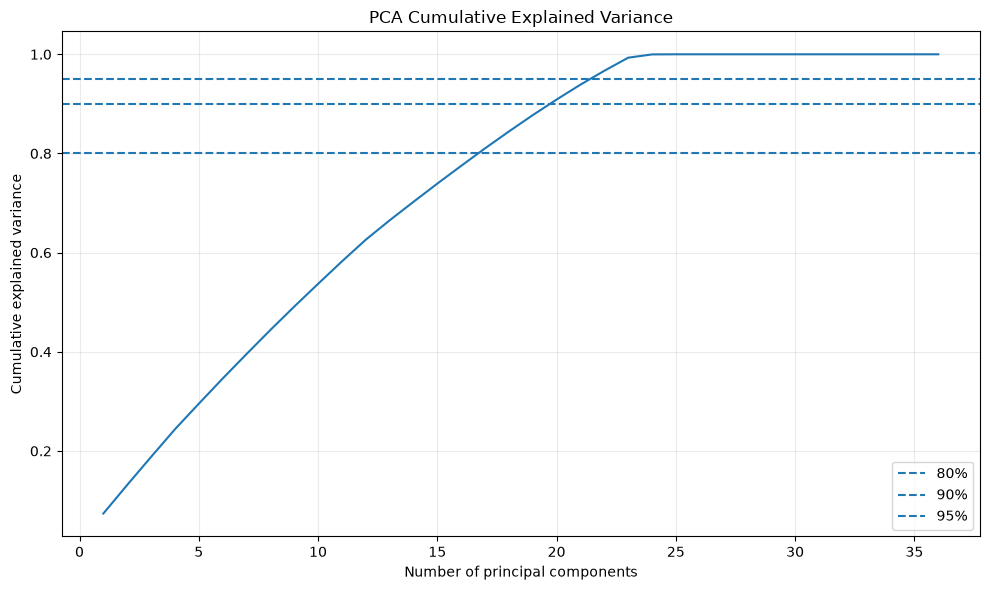

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Choose data-driven PCA component candidates

We evaluate the component counts needed for 80%, 90%, and 95% explained variance.

A small additional candidate set is included only when valid, so the experiment can compare stronger dimensionality reduction against a higher-variance-retention option.

In [21]:
candidate_components = sorted(
    set(
        list(variance_levels.values())
        + [
            min(10, X_train_transformed.shape[1]),
            min(20, X_train_transformed.shape[1])
        ]
    )
)

candidate_components = [
    c for c in candidate_components
    if 1 <= c < X_train_transformed.shape[1]
]

print("PCA component candidates:", candidate_components)

PCA component candidates: [10, 17, 20, 22, 23]


## 6. Baseline vs PCA validation experiment

We use Ridge Regression for this PCA experiment because PCA produces continuous transformed components and Ridge provides a stable linear baseline after scaling.

This experiment answers:

> Does dimensionality reduction preserve enough information to provide comparable predictive performance while reducing the feature space?

The test set remains locked.

In [22]:
def build_preprocessor(feature_columns):
    train_subset = X_train_pca[feature_columns]

    numeric = train_subset.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    categorical = train_subset.select_dtypes(
        include=["object", "str"]
    ).columns.tolist()

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )),
        ("scaler", StandardScaler())
    ])

    return ColumnTransformer([
        ("num", num_pipe, numeric),
        ("cat", cat_pipe, categorical)
    ])

In [23]:
results = []

# Baseline without PCA
baseline_pipeline = Pipeline([
    ("preprocessor", build_preprocessor(selected_features)),
    ("model", Ridge(alpha=1.0))
])

baseline_pipeline.fit(
    X_train_pca[selected_features],
    y_train_pca
)

baseline_pred = baseline_pipeline.predict(
    X_valid_pca[selected_features]
)

results.append({
    "Experiment": "No PCA",
    "Components": np.nan,
    "MAE": mean_absolute_error(y_valid_pca, baseline_pred),
    "RMSE": np.sqrt(mean_squared_error(y_valid_pca, baseline_pred)),
    "R2": r2_score(y_valid_pca, baseline_pred)
})

for n_components in candidate_components:
    pca_pipeline = Pipeline([
        ("preprocessor", build_preprocessor(selected_features)),
        ("pca", PCA(n_components=n_components)),
        ("model", Ridge(alpha=1.0))
    ])

    pca_pipeline.fit(
        X_train_pca[selected_features],
        y_train_pca
    )

    pred = pca_pipeline.predict(
        X_valid_pca[selected_features]
    )

    results.append({
        "Experiment": f"PCA-{n_components}",
        "Components": n_components,
        "MAE": mean_absolute_error(y_valid_pca, pred),
        "RMSE": np.sqrt(mean_squared_error(y_valid_pca, pred)),
        "R2": r2_score(y_valid_pca, pred)
    })

pca_results = pd.DataFrame(results)

display(pca_results)

,Experiment,Components,MAE,RMSE,R2
0,No PCA,NaN,0.570711,1.908495,0.744830
1,PCA-10,10.0,2.104900,3.009156,0.365638
2,PCA-17,17.0,1.998788,2.913105,0.405488
3,PCA-20,20.0,1.545288,2.477172,0.570107
4,PCA-22,22.0,0.931926,2.053728,0.704516
5,PCA-23,23.0,0.595059,1.916877,0.742583


## 7. PCA decision

Use the **actual validation results** above.

PCA is justified only if it provides a useful trade-off between:
- predictive performance,
- dimensionality reduction,
- explained variance,
- and model simplicity.

If the no-PCA baseline performs better and PCA does not provide a meaningful operational advantage, the production pipeline should remain **without PCA**.

That is a valid result: PCA was evaluated scientifically and rejected rather than forced into the project.

In [24]:
best_pca_or_baseline = pca_results.sort_values(
    "RMSE",
    ascending=True
).iloc[0]

print("Lowest validation RMSE:")
print(best_pca_or_baseline.to_dict())

baseline_rmse = pca_results.loc[
    pca_results["Experiment"] == "No PCA",
    "RMSE"
].iloc[0]

best_experiment = best_pca_or_baseline["Experiment"]

if best_experiment == "No PCA":
    pca_decision = (
        "PCA was evaluated but the no-PCA baseline achieved the lowest "
        "validation RMSE. Retain the non-PCA representation for production."
    )
else:
    pca_decision = (
        f"{best_experiment} achieved the lowest validation RMSE in this "
        "experiment. PCA remains a candidate for further model comparison."
    )

print("\nDecision:")
print(pca_decision)

Lowest validation RMSE:
{'Experiment': 'No PCA', 'Components': nan, 'MAE': 0.5707113933361745, 'RMSE': 1.9084951530069865, 'R2': 0.7448297033897711}

Decision:
PCA was evaluated but the no-PCA baseline achieved the lowest validation RMSE. Retain the non-PCA representation for production.


In [25]:
OUTPUT_DIR = Path("../outputs/metrics")
FIGURE_DIR = Path("../outputs/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pca_results.to_csv(
    OUTPUT_DIR / "pca_experiment_results.csv",
    index=False
)

pca_summary = {
    "post_preprocessing_dimensions": int(X_train_transformed.shape[1]),
    "variance_threshold_components": variance_levels,
    "candidate_components": candidate_components,
    "decision": pca_decision
}

with open(
    OUTPUT_DIR / "pca_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(pca_summary, f, indent=2)

print("PCA experiment artifacts saved.")

PCA experiment artifacts saved.


# PCA Experiment Summary

### What was tested

- No-PCA Ridge baseline
- Multiple PCA component counts selected from actual explained-variance requirements

### Leakage controls

- Test data was locked.
- Preprocessing was fitted only on training data.
- PCA was fitted only inside the training pipeline.
- Validation data was used for experiment comparison.

### Next phase

Proceed to **`07_model_experiments.ipynb`**.

There we will compare multiple regression algorithms and establish the final production model based on actual cross-validation and validation/test evidence.
